# Notebook 2 — Feature Engineering

| Trường | Nội dung |
|---|---|
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 2 of 7 |
| **Input** | `data/raw/sp500_clean.csv` |
| **Output** | `data/processed/sp500_features.csv` · figures trong `reports/figures/nb2/` |
| **Trọng tâm** | Log Return · Rolling Volatility · MA · Lag · Label Construction |

## 1. Import & Cấu hình

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

FIGURES_DIR  = '../reports/figures/nb2'
PROCESSED_DIR = '../data/processed'

os.makedirs(FIGURES_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('✓ Imports OK')

✓ Imports OK


## 2. Load dữ liệu sạch từ Notebook 1

In [65]:
df = pd.read_csv('../data/raw/sp500_clean.csv', index_col=0, parse_dates=True)
df = df.sort_index()

print(f'Loaded: {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}')
print(df.head(3))

Loaded: (2514, 5)  |  2015-01-02 → 2024-12-27
                  Close         High          Low         Open      Volume
Date                                                                      
2015-01-02  2058.199951  2072.360107  2046.040039  2058.899902  2708700000
2015-01-05  2020.579956  2054.439941  2017.339966  2054.439941  3799120000
2015-01-06  2002.609985  2030.250000  1992.439941  2022.150024  4460110000


## 3. Feature Engineering

### 3.1 Log Return

$$r_t = \log\left(\frac{\text{Close}_t}{\text{Close}_{t-1}}\right)$$

Log return ổn định hơn simple return và phù hợp cho statistical modeling.

In [66]:
df['Return'] = np.log(df['Close'] / df['Close'].shift(1))
print(f'Return — mean={df["Return"].mean():.6f}  std={df["Return"].std():.6f}')

Return — mean=0.000424  std=0.011272


### 3.2 Rolling Volatility (10-day)

$$RV_t = \sqrt{\frac{1}{n}\sum_{i=0}^{n-1}(r_{t-i} - \bar{r})^2}$$

In [67]:
df['Volatility'] = df['Return'].rolling(window=10).std()
print(f'Volatility — mean={df["Volatility"].mean():.6f}  max={df["Volatility"].max():.6f}')

Volatility — mean=0.009124  max=0.075383


### 3.3 Moving Averages & MA Ratio

$$MA_t^{(k)} = \frac{1}{k}\sum_{i=0}^{k-1}\text{Close}_{t-i} \qquad MA\_Ratio = \frac{MA_{10}}{MA_{30}}$$

In [68]:
df['MA10']     = df['Close'].rolling(window=10).mean()
df['MA30']     = df['Close'].rolling(window=30).mean()
df['MA_Ratio'] = df['MA10'] / df['MA30']
print(f'MA_Ratio — mean={df["MA_Ratio"].mean():.6f}  std={df["MA_Ratio"].std():.6f}')

MA_Ratio — mean=1.004430  std=0.020867


### 3.4 Lag Features

$$Lag1 = r_{t-1} \qquad Lag2 = r_{t-2}$$

In [69]:
df['Lag1'] = df['Return'].shift(1)
df['Lag2'] = df['Return'].shift(2)

### 3.5 Intraday Range

$$\text{Intraday\_Range}_t = \frac{\text{High}_t - \text{Low}_t}{\text{Close}_t}$$

In [70]:
df['Intraday_Range'] = (df['High'] - df['Low']) / df['Close']

### 3.6 Close Position

$$\text{Close\_Position}_t = \frac{\text{Close}_t - \text{Low}_t}{\text{High}_t - \text{Low}_t}$$

Phản ánh vị trí giá đóng cửa trong dải biến động trong ngày (0 = đóng ở mức thấp nhất, 1 = cao nhất).

In [71]:
hl_range = df['High'] - df['Low']
df['Close_Position'] = np.where(
    hl_range > 0,
    (df['Close'] - df['Low']) / hl_range,
    0.5
)

### 3.7 Volume Change

$$\text{Volume\_Change}_t = \frac{\text{Volume}_t - \text{Volume}_{t-1}}{\text{Volume}_{t-1}}$$

In [72]:
df['Volume_Change'] = df['Volume'].pct_change().clip(-5, 5)

In [73]:
# ==========================================================
# Volume Ratio
# ==========================================================

df['Volume_MA20'] = df['Volume'].rolling(20).mean()

df['Volume_Ratio'] = (
    df['Volume']
    / (df['Volume_MA20'] + 1e-8)
)

In [74]:
# ==========================================================
# Volatility Ratio
# ==========================================================

df['Volatility_10'] = (
    df['Return']
    .rolling(10)
    .std()
)

df['Volatility_30'] = (
    df['Return']
    .rolling(30)
    .std()
)

df['Volatility_Ratio'] = (
    df['Volatility_10']
    / (df['Volatility_30'] + 1e-8)
)

## 4. Xây dựng Target Label

$$\text{Label}_t = \begin{cases} 1, & |r_{t+1}| > \tau_t \\ 0, & |r_{t+1}| \leq \tau_t \end{cases}$$

trong đó $\tau_t$ là **ngưỡng động** (rolling quantile):

$$\tau_t = Q_{0.80}\!\left(\,|r_{t-126}|,\, |r_{t-125}|,\, \ldots,\, |r_{t-1}|\,\right)$$

- **Rolling window** 126 phiên (~6 tháng giao dịch) — ngưỡng thích nghi với chế độ thị trường (bull/bear/crisis).  
- **`shift(1)` trên `|Return|`** trước khi rolling — đảm bảo $\tau_t$ chỉ dùng dữ liệu đến ngày $t-1$, không có data leakage.  
- **`shift(-1)` trên `Return`** để lấy $r_{t+1}$ — label phản ánh biến động của phiên **kế tiếp**, đúng với bài toán dự báo.  
- **Top 20%** biến động mạnh nhất được gán Label = 1 → class balance xấp xỉ 80/20.

In [83]:
# ============================================================
# Dynamic Label (Rolling Quantile - No Data Leakage)
# ============================================================

WINDOW = 126         # ~6 tháng giao dịch
QUANTILE = 0.80       # Top 20% biến động mạnh nhất

# Threshold động:
# - shift(1): chỉ sử dụng dữ liệu đến ngày t-1
# - rolling(): tính trên WINDOW phiên gần nhất
df["Threshold"] = (
    df["Return"]
      .abs()
      .shift(1)
      .rolling(window=WINDOW, min_periods=WINDOW)
      .quantile(QUANTILE)
)

# Label:
# Dự báo xem |Return(t+1)| có vượt ngưỡng tại thời điểm t hay không
df["Label"] = (
    df["Return"].shift(-1).abs() > df["Threshold"]
).astype(int)

# Các dòng đầu chưa đủ WINDOW phiên sẽ có Threshold = NaN
# ✅ Bỏ reset_index(drop=True) để giữ nguyên DatetimeIndex
df = df.dropna(subset=["Threshold"])

# ============================================================
# Class Balance
# ============================================================

label_counts = df["Label"].value_counts().sort_index()

print("=" * 50)
print("Dynamic Label Statistics")
print("=" * 50)
print(f"Window                : {WINDOW} trading days")
print(f"Quantile              : Top {(1-QUANTILE)*100:.0f}%")
print(f"Average Threshold     : {df['Threshold'].mean():.4f}")
print(f"Median Threshold      : {df['Threshold'].median():.4f}")
print(f"Index type            : {type(df.index).__name__}")   # kiểm tra nhanh
print(f"Index sample          : {df.index[:3].tolist()}")     # phải ra 2015-xx-xx
print()

print("=== Class Balance ===")
print(f"Label 0 (Normal)          : {label_counts[0]:5d} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"Label 1 (Strong Movement) : {label_counts[1]:5d} ({label_counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance Ratio           : {label_counts[0]/label_counts[1]:.2f}:1")

Dynamic Label Statistics
Window                : 126 trading days
Quantile              : Top 20%
Average Threshold     : 0.0119
Median Threshold      : 0.0103
Index type            : DatetimeIndex
Index sample          : [Timestamp('2016-02-18 00:00:00'), Timestamp('2016-02-19 00:00:00'), Timestamp('2016-02-22 00:00:00')]

=== Class Balance ===
Label 0 (Normal)          :  1806 (81.0%)
Label 1 (Strong Movement) :   425 (19.0%)
Imbalance Ratio           : 4.25:1


## 5. Visualization — Feature Analysis

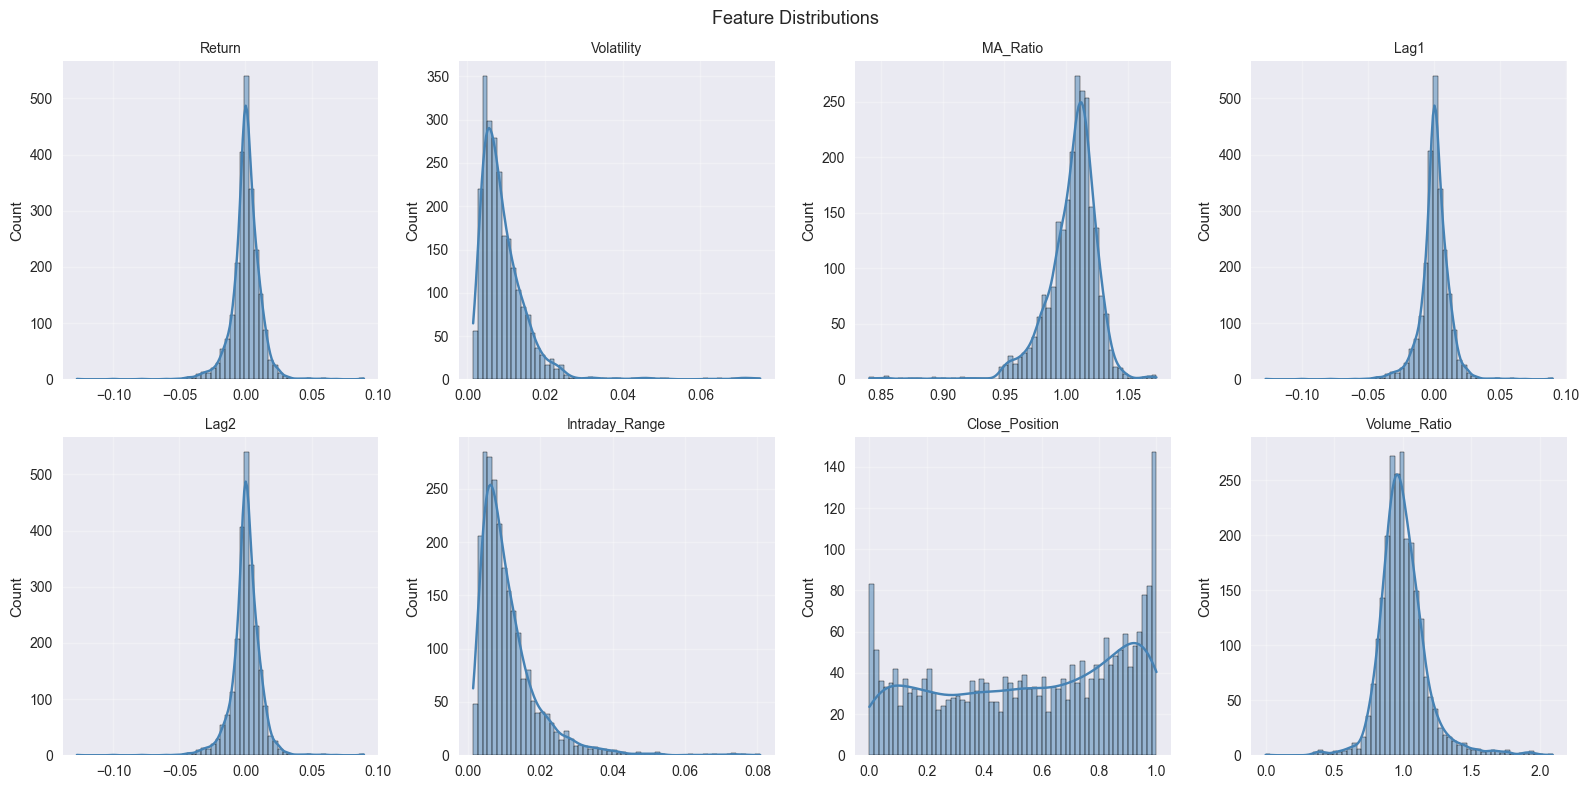

Saved → ../reports/figures/nb2/feature_distributions.png


In [76]:
FEATURE_COLS = [
    'Return',
    'Volatility',
    'MA_Ratio',
    'Lag1',
    'Lag2',
    'Intraday_Range',
    'Close_Position',
    'Volume_Ratio',
    'Volatility_Ratio'
]

# ── Visualization 1: Feature distributions ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions', fontsize=13)

for ax, feat in zip(axes.flatten(), FEATURE_COLS):
    sns.histplot(df[feat].dropna(), bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/feature_distributions.png')

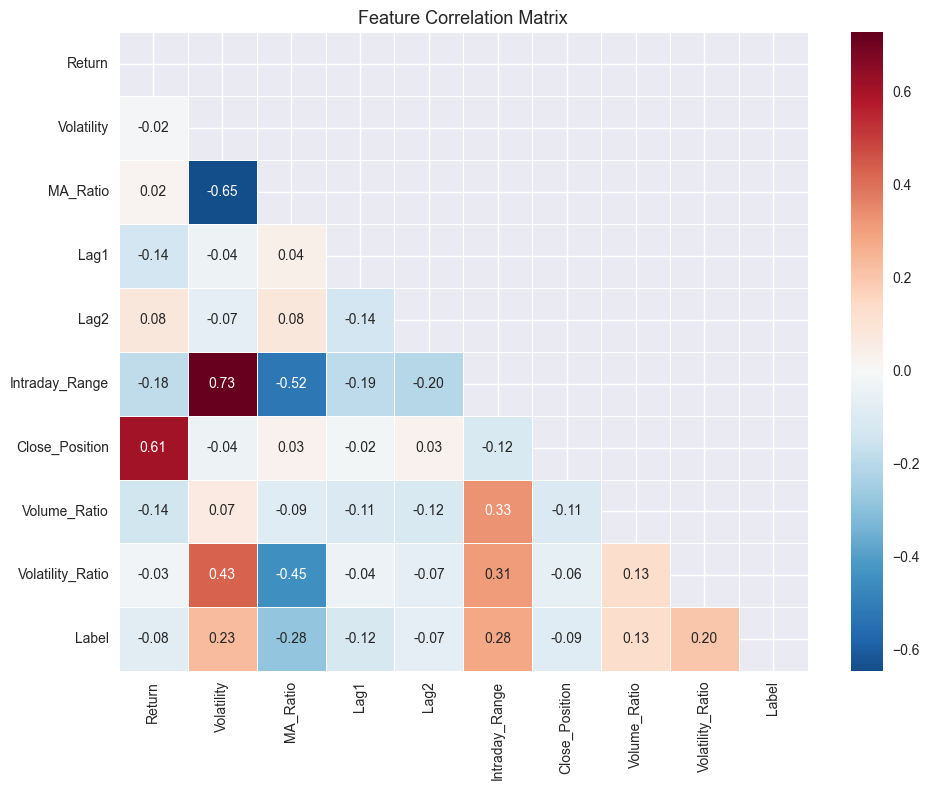

Saved → ../reports/figures/nb2/correlation_matrix.png


In [77]:
# ── Visualization 2: Correlation matrix ────────────────────────────────────
df_plot = df[FEATURE_COLS + ['Label']].dropna()
corr    = df_plot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/correlation_matrix.png')

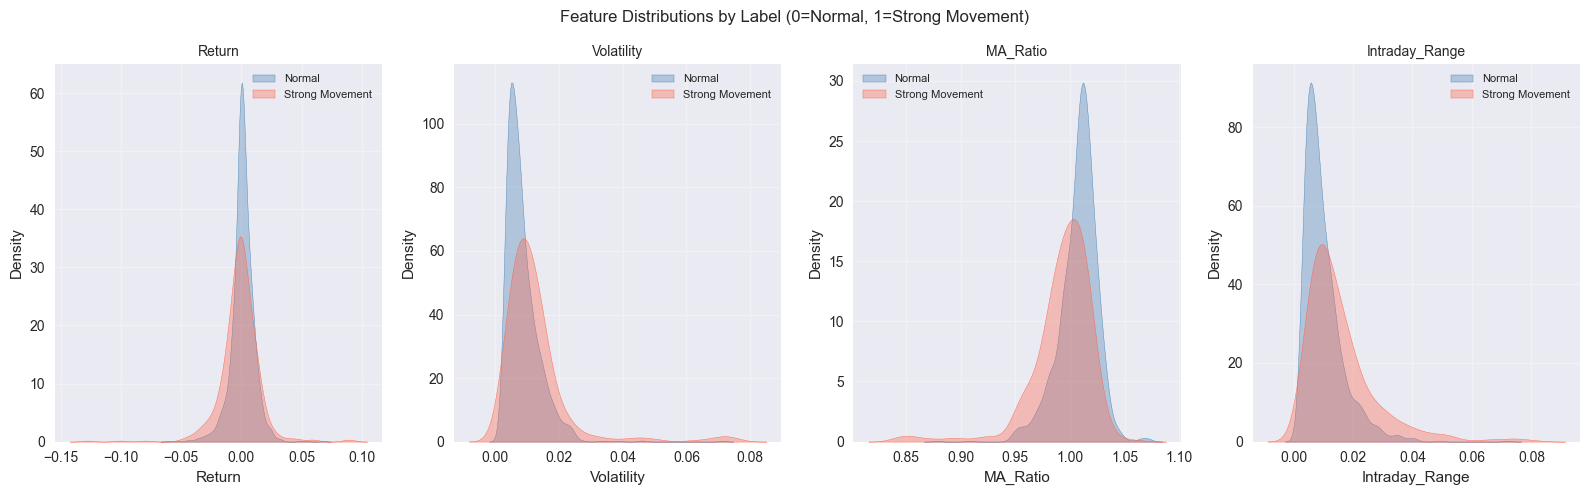

Saved → ../reports/figures/nb2/features_by_label.png


In [78]:
# ── Visualization 3: Features theo Label ───────────────────────────────────
key_feats = ['Return', 'Volatility', 'MA_Ratio', 'Intraday_Range']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Feature Distributions by Label (0=Normal, 1=Strong Movement)', fontsize=12)

for ax, feat in zip(axes, key_feats):
    for label, color, name in [(0, 'steelblue', 'Normal'), (1, 'tomato', 'Strong Movement')]:
        data = df_plot.loc[df_plot['Label'] == label, feat]
        sns.kdeplot(data, ax=ax, label=name, color=color, fill=True, alpha=0.35)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/features_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/features_by_label.png')

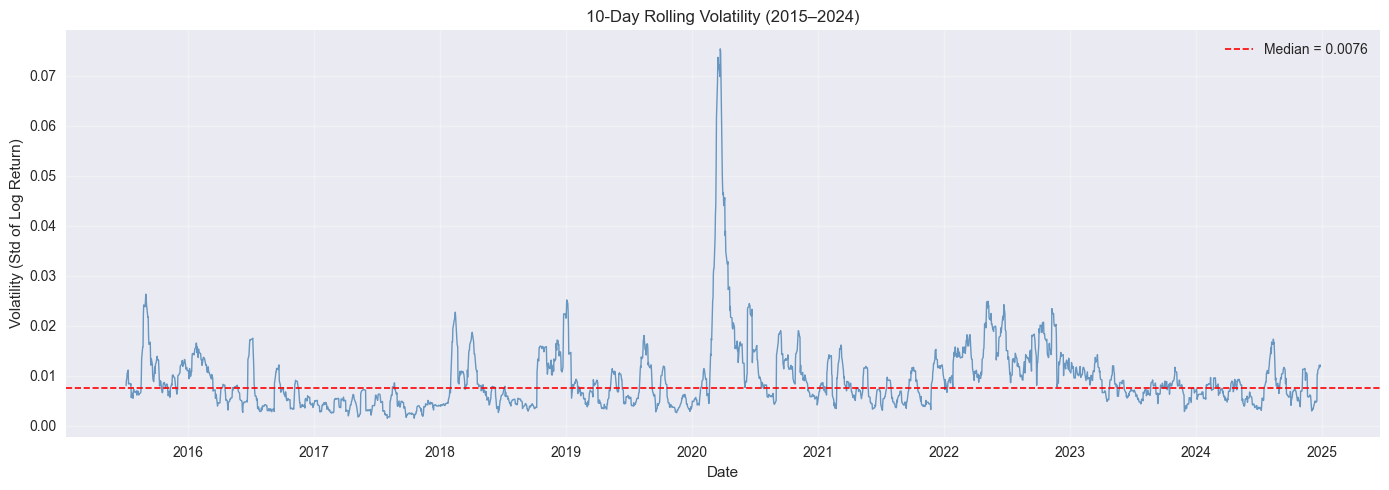

Saved → ../reports/figures/nb2/volatility_timeline.png


In [79]:
# ── Visualization 4: 10-Day Rolling Volatility timeline ────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Volatility'], linewidth=1, color='steelblue', alpha=0.8)
ax.axhline(df['Volatility'].median(), color='red', linestyle='--',
           linewidth=1.2, label=f'Median = {df["Volatility"].median():.4f}')
ax.set_title('10-Day Rolling Volatility (2015–2024)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std of Log Return)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/volatility_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/volatility_timeline.png')

## 6. Drop NaN và Lưu dataset

In [81]:
FEATURE_COLS = [
    'Return',
    'Volatility',
    'MA_Ratio',
    'Lag1',
    'Lag2',
    'Intraday_Range',
    'Close_Position',
    'Volume_Ratio',
    'Volatility_Ratio'
]

df_feat = df[FEATURE_COLS + ['Label']].copy()   # <-- sửa ở đây
df_feat.index.name = 'Date'

n_before = len(df_feat)
df_feat  = df_feat.dropna()
n_after  = len(df_feat)

print(f'Rows before dropna : {n_before}')
print(f'Rows after dropna  : {n_after}  (dropped {n_before - n_after} rows due to rolling window NaN)')
print()
print('Thống kê mô tả final features:')
print(df_feat.describe().round(4).to_string())

output_path = '../data/processed/sp500_features.csv'
df_feat.to_csv(output_path)
print(f'\n✓ Saved → {output_path}')
print(f'  Shape   : {df_feat.shape}')
print(f'  Features: {FEATURE_COLS}')   # <-- sửa ở đây luôn

Rows before dropna : 2387
Rows after dropna  : 2387  (dropped 0 rows due to rolling window NaN)

Thống kê mô tả final features:
          Return  Volatility   MA_Ratio       Lag1       Lag2  Intraday_Range  Close_Position  Volume_Ratio  Volatility_Ratio      Label
count  2387.0000   2387.0000  2387.0000  2387.0000  2387.0000       2387.0000       2387.0000     2387.0000         2387.0000  2387.0000
mean      0.0004      0.0092     1.0045     0.0004     0.0004          0.0111          0.5588        1.0028            0.9623     0.1986
std       0.0114      0.0069     0.0212     0.0114     0.0114          0.0083          0.3210        0.1781            0.2857     0.3990
min      -0.1277      0.0015     0.8409    -0.1277    -0.1277          0.0015          0.0000        0.0000            0.2491     0.0000
25%      -0.0037      0.0051     0.9952    -0.0037    -0.0037          0.0057          0.2719        0.9042            0.7550     0.0000
50%       0.0007      0.0076     1.0084     0.0007